<a href="https://colab.research.google.com/github/Rishitha110506/Machine-Learning/blob/main/ML_Lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MACHINE LEARNING ASSIGNMENT 10

NAME : KAMPALLI RISHITHA

REG NO : BL.SC.U4AIE24020

SEC : D.Sec

loading dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving BERT_Embeddings.xlsx to BERT_Embeddings.xlsx


A1)  Correlation analysis and heatmap plot

In this code we perform correlation analysis on our feature set (BERT embeddings) to understand relationships between features. Since the dataset contains a very high number of features (768), a subset is selected for visualization clarity. The correlation matrix is computed using Pearson correlation, and a heatmap is plotted using seaborn. The heatmap helps identify highly correlated features, redundancy, and potential multicollinearity in the dataset.

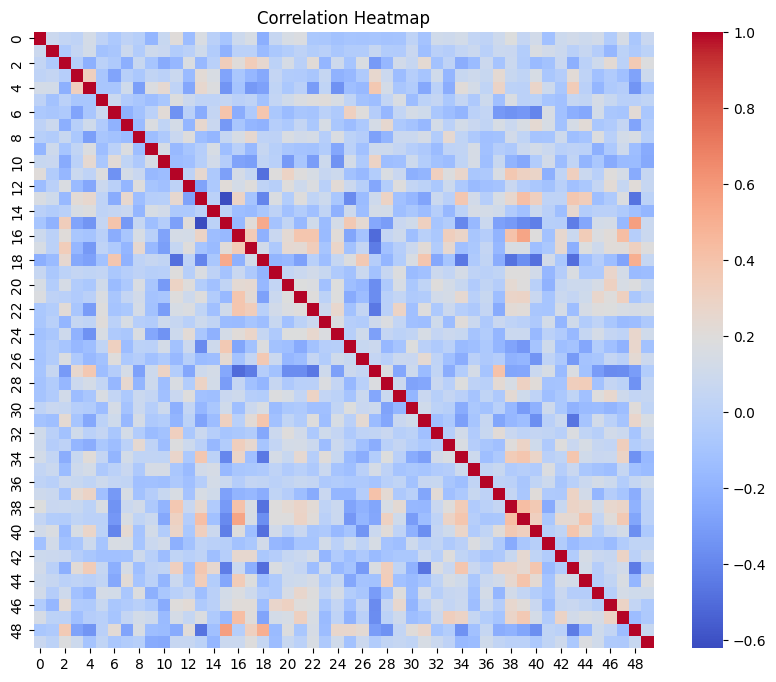

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(path):
    return pd.read_excel(path)

def get_features(data):
    return data.iloc[:, 0:768]

def compute_correlation(X):
    return X.corr()

def plot_heatmap(corr):
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='coolwarm')
    plt.title("Correlation Heatmap")


data = load_data("BERT_Embeddings.xlsx")
X = get_features(data)

corr_matrix = compute_correlation(X.iloc[:, :50])
plot_heatmap(corr_matrix)

plt.show()

A2)  PCA with 99% Variance and we used classification models

In this part, Principal Component Analysis (PCA) is applied to reduce the dimensionality of the dataset while retaining 99% of the variance. First, the features are standardized to ensure equal contribution. PCA transforms the original features into a smaller set of principal components. These transformed features are then used to train classification models such as Logistic Regression, Random Forest, and SVM. The performance is evaluated using accuracy, allowing comparison with the original high-dimensional data.

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

def load_data(path):
    return pd.read_excel(path)

def split_data(data):
    X = data.iloc[:, 0:768]
    y = data['label']
    return X, y

def apply_pca(X, variance):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=variance)
    return pca.fit_transform(X_scaled)

def train_models(X_train, X_test, y_train, y_test):
    models = {
        "Logistic": LogisticRegression(max_iter=1000),
        "RandomForest": RandomForestClassifier(),
        "SVM": SVC()
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results[name] = accuracy_score(y_test, preds)

    return results


data = load_data("BERT_Embeddings.xlsx")
X, y = split_data(data)

X_pca = apply_pca(X, 0.99)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

results = train_models(X_train, X_test, y_train, y_test)

print(results)

{'Logistic': 0.49019607843137253, 'RandomForest': 0.5339366515837104, 'SVM': 0.555052790346908}


A3)  PCA (95% variance)

This code is similar to A2 but uses a lower threshold of 95% explained variance. This results in fewer principal components and higher dimensionality reduction. The same classification models are trained and evaluated on the reduced dataset. The purpose is to analyze the trade-off between dimensionality reduction and model performance, and to observe whether reducing more features affects accuracy.

In [4]:
X_pca = apply_pca(X, 0.95)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

results = train_models(X_train, X_test, y_train, y_test)

print(results)

{'Logistic': 0.4781297134238311, 'RandomForest': 0.5460030165912518, 'SVM': 0.5595776772247361}


The performance of models using 99% and 95% explained variance is very similar. This indicates that most of the important information is captured within 95% variance itself. Increasing the number of components beyond this does not significantly improve model accuracy, suggesting diminishing returns from additional features.

A4)  Sequential Feature Selection

Sequential Feature Selection (SFS) is used to select a subset of important features from the dataset. Starting with no features, the algorithm incrementally adds features that improve model performance. In this code, Logistic Regression is used as the base model to select a fixed number of features. The selected features are then used to train a classification model, and performance is evaluated. This approach helps in identifying the most relevant features compared to PCA-based reduction.

In [12]:
# A4: Sequential Feature Selection (Optimized)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
def load_data(path):
    return pd.read_excel(path)

# =========================
# SPLIT FEATURES & LABEL
# =========================
def split_data(data):
    X = data.iloc[:, 0:768]
    y = data['label']
    return X, y

# =========================
# REDUCE FEATURES (IMPORTANT STEP)
# =========================
def reduce_features(X):
    return X.iloc[:, :100]   # reduce from 768 → 100

# =========================
# APPLY SEQUENTIAL SELECTION
# =========================
def select_features(X, y):
    base_model = DecisionTreeClassifier()

    sfs = SequentialFeatureSelector(
        base_model,
        n_features_to_select=10,
        direction='forward'
    )

    sfs.fit(X, y)
    return sfs.get_support(indices=True)

# =========================
# TRAIN FINAL MODEL
# =========================
def train_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

# =========================
# MAIN
# =========================
data = load_data("BERT_Embeddings.xlsx")
X, y = split_data(data)

# Step 1: Reduce features
X_small = reduce_features(X)

# Step 2: Apply SFS
selected_indices = select_features(X_small, y)

# Step 3: Create selected dataset
X_selected = X_small.iloc[:, selected_indices]

# Step 4: Train model
accuracy = train_model(X_selected, y)

print("Selected feature indices:", selected_indices)
print("Model Accuracy:", accuracy)

Selected feature indices: [ 1  5 22 27 29 44 49 90 94 97]
Model Accuracy: 0.5399698340874811


output Explanation

Sequential Feature Selection selected 10 important features from the reduced dataset(100). Using only these features, the model achieved about 54% accuracy, which is similar to PCA results. This shows that a small number of relevant features can give comparable performance while reducing dimensionality.

Reason :

The number of features was reduced to 100 to decrease the computational cost of Sequential Feature Selection. Since the original dataset has 768 features, running SFS on all features would take a very long time. Reducing the feature size helps speed up the process while still retaining enough information for meaningful feature selection.


 SHAP (SHapley Additive exPlanations) is a method used to explain machine learning models. It assigns an importance value to each feature, showing how much it contributes to a prediction based on game theory.

SHAP is used to understand model behavior by identifying important features and explaining predictions. It helps improve transparency, detect issues, and build trust in the model.

A5)  LIME and SHAP Explainability

This code focuses on interpreting the trained model using explainable AI techniques. LIME (Local Interpretable Model-Agnostic Explanations) explains individual predictions by approximating the model locally and highlighting important features for a specific instance. SHAP (SHapley Additive exPlanations) provides a global explanation by assigning importance values to each feature based on their contribution to the model’s output. These methods help in understanding model behavior and comparing interpretability techniques.

In [8]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=28b72f54e7a3256ca48b4509a843254401dbf0dce51a3670e10cc9f6e21bfe63
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [10]:
!pip install shap

LIME: [('709 <= -0.15', -0.006155473377708219), ('702 <= -0.17', -0.005438845481704963), ('-0.02 < 741 <= 0.10', 0.00539087675047675), ('650 > -0.01', -0.004924258346130639), ('-0.16 < 55 <= -0.07', -0.00481857227884736), ('0.08 < 563 <= 0.19', -0.004798218927053157), ('-0.32 < 209 <= -0.23', 0.004033467145938443), ('152 <= -0.06', -0.0038953134708125453), ('0.03 < 193 <= 0.13', -0.0036147163475898428), ('604 <= -0.14', 0.003489322922867663)]


 97%|=================== | 292/300 [00:15<00:00]       

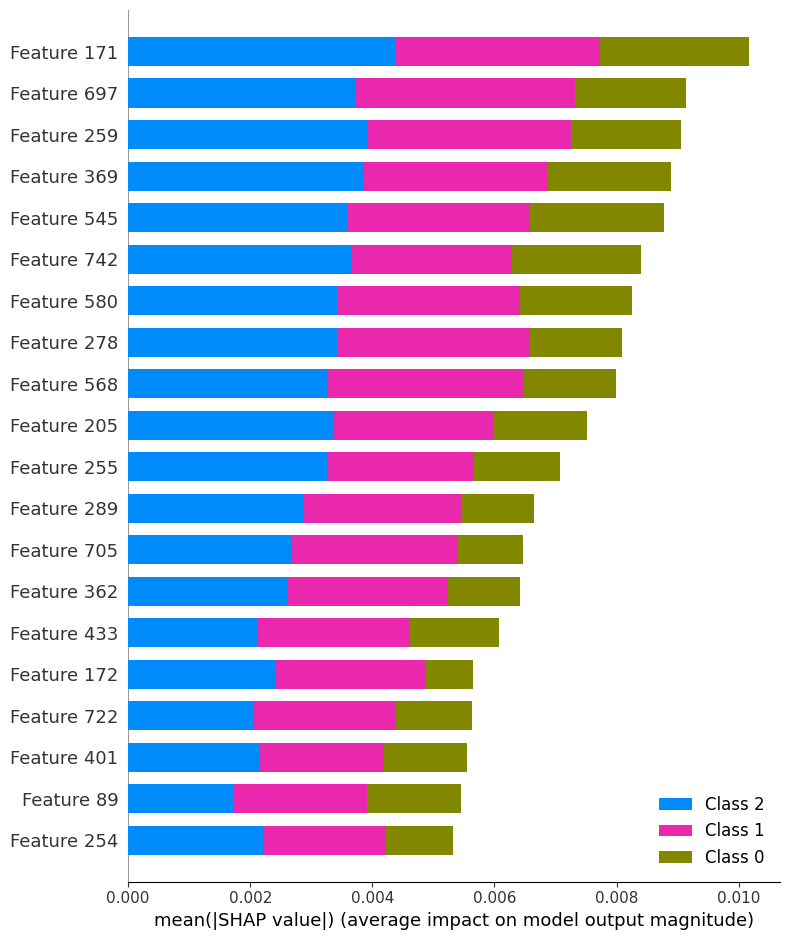

In [11]:
import pandas as pd
import numpy as np
import shap
from lime.lime_tabular import LimeTabularExplainer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

def load_data(path):
    return pd.read_excel(path)

def split_data(data):
    X = data.iloc[:, 0:768]
    y = data['label']
    return X, y

def train_model(X_train, y_train):
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    return model

def lime_explanation(X_train, X_test, model):
    explainer = LimeTabularExplainer(
        training_data=np.array(X_train),
        mode='classification'
    )

    explanation = explainer.explain_instance(
        X_test[0],
        model.predict_proba
    )

    return explanation

def shap_explanation(model, X_train):
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_train[:100])
    return shap_values


data = load_data("BERT_Embeddings.xlsx")
X, y = split_data(data)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

model = train_model(X_train, y_train)

lime_exp = lime_explanation(X_train, X_test, model)
print("LIME:", lime_exp.as_list())

shap_vals = shap_explanation(model, X_train)
shap.summary_plot(shap_vals, X_train)

Short Explanation (LIME + SHAP)

LIME explains a single prediction by showing how features positively or negatively influence it. SHAP explains overall model behavior by showing feature importance across multiple samples. In both cases, the small values indicate that many features contribute slightly, rather than a few features having a strong impact.
